# Laboratorio 4: Detección de Fraude con Regresión Logística

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

## Seguridad y privacidad (antes de entrenar)
- No usar credenciales en notebook.
- Excluir identificadores sensibles (`nameOrig`, `nameDest`).
- No versionar `.env` ni datasets locales.

## 1) Cargar el conjunto de datos

### Fuente de datos utilizada

`https://hybridge-education-machine-learning-datasets.s3.us-east-1.amazonaws.com/Fraud.csv`

In [2]:
DATA_URL = "https://hybridge-education-machine-learning-datasets.s3.us-east-1.amazonaws.com/Fraud.csv"
LOCAL_FRAUD_PATH = "data/Fraud.csv"

try:
    df = pd.read_csv(DATA_URL)
    data_source = DATA_URL
except Exception as e:
    print(f"No fue posible leer desde URL ({e}). Se intenta ruta local: {LOCAL_FRAUD_PATH}")
    df = pd.read_csv(LOCAL_FRAUD_PATH)
    data_source = LOCAL_FRAUD_PATH

print(f"Fuente de datos: {data_source}")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
df.head()

Fuente de datos: https://hybridge-education-machine-learning-datasets.s3.us-east-1.amazonaws.com/Fraud.csv
Filas: 6,362,620
Columnas: 11


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 2) Exploración de datos

In [3]:
print(df.info())
print('\nValores nulos por columna:')
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB
None

Valores nulos por columna:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


Conteo de clases:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Porcentaje por clase:
isFraud
0    99.8709
1     0.1291
Name: proportion, dtype: float64


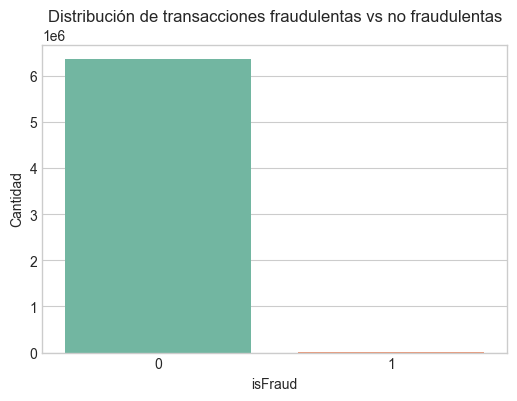

In [4]:
fraud_counts = df['isFraud'].value_counts()
fraud_ratio = df['isFraud'].value_counts(normalize=True) * 100

print('Conteo de clases:')
print(fraud_counts)
print('\nPorcentaje por clase:')
print(fraud_ratio.round(4))

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='isFraud', palette='Set2')
plt.title('Distribución de transacciones fraudulentas vs no fraudulentas')
plt.xlabel('isFraud')
plt.ylabel('Cantidad')
plt.show()

In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols].describe().T.head(15)

,count,mean,std,min,25%,50%,75%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00
isFlaggedFraud,6362620.0,2.514687e-06,1.585775e-03,0.0,0.00,0.000,0.000000e+00,1.000000e+00


## 3) Preprocesamiento

In [6]:
SENSITIVE_ID_COLS = ['nameOrig', 'nameDest']
X = df.drop(columns=['isFraud'])
y = df['isFraud']

X = X.drop(columns=[c for c in SENSITIVE_ID_COLS if c in X.columns])
X = pd.get_dummies(X, drop_first=True)

print('Columnas excluidas por seguridad:', [c for c in SENSITIVE_ID_COLS if c in df.columns])
print(f'Características después de dummies: {X.shape[1]}')
X.head()

Columnas excluidas por seguridad: ['nameOrig', 'nameDest']
Características después de dummies: 11


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,0,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,0,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,False,False,True,False


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Fraude en train (%):', round(y_train.mean() * 100, 4))
print('Fraude en test (%):', round(y_test.mean() * 100, 4))

Train shape: (5090096, 11)
Test shape: (1272524, 11)
Fraude en train (%): 0.1291
Fraude en test (%): 0.1291


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4) Entrenamiento del modelo

In [9]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)
log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

## 5) Evaluación del desempeño

In [10]:
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

print('Classification report:\n')
print(classification_report(y_test, y_pred, digits=4))

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
print(f'ROC AUC: {roc_auc:.4f}')
print(f'PR AUC: {pr_auc:.4f}')

Classification report:

              precision    recall  f1-score   support

           0     1.0000    0.9513    0.9750   1270881
           1     0.0252    0.9744    0.0492      1643

    accuracy                         0.9513   1272524
   macro avg     0.5126    0.9629    0.5121   1272524
weighted avg     0.9987    0.9513    0.9738   1272524

ROC AUC: 0.9947
PR AUC: 0.5937


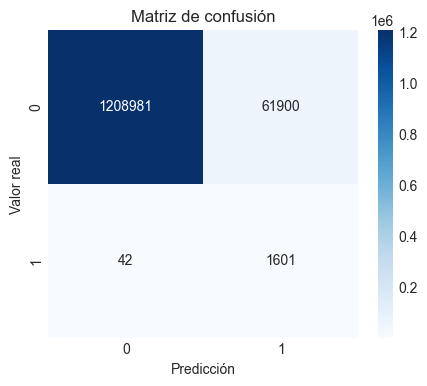

In [11]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

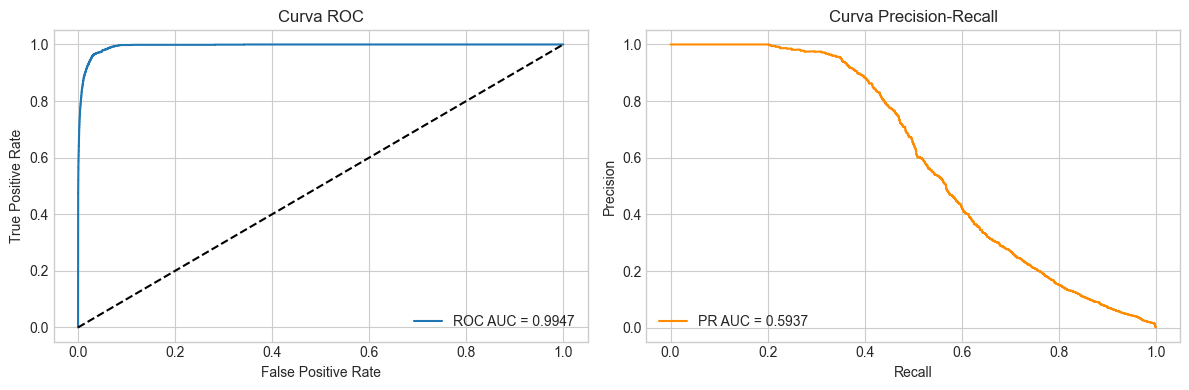

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
precision, recall, _ = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.4f}')
ax[0].plot([0,1],[0,1],'k--')
ax[0].set_title('Curva ROC')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend(loc='lower right')

ax[1].plot(recall, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
ax[1].set_title('Curva Precision-Recall')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend(loc='lower left')
plt.tight_layout()
plt.show()

## Conclusiones
- Pipeline completo implementado.
- Se excluyen identificadores sensibles.
- Métricas robustas para desbalanceo.